# F112 All Sequences Tree Preview

This notebook loads the Auspice/Nextstrain JSON tree for the F112 dataset and renders a baltic phylogeny coloured by a chosen geographic trait. Adjust the configuration cell below if you want to use a different tree or change the colouring attribute (e.g. `country`).

In [8]:
# Imports and plotting defaults
%matplotlib inline
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl

# Ensure local baltic module is imported (falls back to pip installation otherwise)
project_root = Path.cwd()
sys.path.insert(0, str(project_root / "Scripts"))
import baltic as bt

mpl.rcParams.update({
    "font.family": "Helvetica Neue",
    "font.size": 16,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Using baltic from: {bt.__file__}")

Using baltic from: /Users/ricardorivero/Documents/GitHub/DENV_Epi/Scripts/baltic.py


In [9]:
# Tree configuration
from datetime import datetime
from typing import Callable

TREE_PATH = Path("../Revision/dengue_denv2_genome_dates.nexus")  # Nexus with decimal-time branch lengths
assert TREE_PATH.exists(), f"Nexus tree not found at {TREE_PATH}"

ll = bt.loadNexus(
    str(TREE_PATH),
    absoluteTime=True,
    sortBranches=True,
)

ll.sortBranches(descending=False)

COLOUR_TRAIT = "country"
DEFAULT_COLOUR = "#cccccc"

print(f"Loaded tree with {len(ll.Objects)} branches")
print(f"Most recent sample: {getattr(ll, 'mostRecent', float('nan')):.3f}")
print(f"Tree height: {ll.treeHeight:.3f} years")

available_traits = sorted({key for branch in ll.Objects for key in branch.traits})
print("Available traits (first 10):", available_traits[:10])

Loaded tree with 3215 branches
Most recent sample: 2024.596
Tree height: 6.367 years
Available traits (first 10): ['clade_membership', 'country', 'divergence', 'genotype', 'host', 'name', 'num_date', 'num_date_confidence', 'region', 'strain']


In [10]:
# Plot helpers
import pandas as pd

# Build palette from meta (if available) and fall back to default colour otherwise
palette = ll.cmap.get(COLOUR_TRAIT, {}) if hasattr(ll, "cmap") else {}

colors = {
    "Bolivia": "#c7522a",
    "Brazil": "#7e9c66",
    "Colombia": "#e09f3e",
    "Ecuador": "#335c67",
    "Paraguay": "#e29578",
    "Peru": "#3e909d",
    "USA": "#bd0a31",
    "Bangladesh": "#B56A7A",
    "Venezuela": "#4363d8",
    "Caribbean": "#9c6ade"
}

c_func = lambda k: colors[k.traits['country']] if 'country' in k.traits and k.traits['country'] in colors else '#FFCD00'


def decimal_year_to_date(decimal_year: float) -> pd.Timestamp:
    '''Convert a decimal year (e.g. 2024.25) into a pandas timestamp.'''
    year = int(decimal_year)
    fraction = decimal_year - year
    start_of_year = pd.Timestamp(f"{year}-01-01")
    days_in_year = (pd.Timestamp(f"{year + 1}-01-01") - start_of_year).days
    return start_of_year + pd.to_timedelta(fraction * days_in_year, unit="D")


most_recent_year = getattr(ll, "mostRecent", None)
if most_recent_year is not None:
    most_recent_date = decimal_year_to_date(most_recent_year)
    print("Most recent collection date:", most_recent_date.date())


Most recent collection date: 2024-08-06


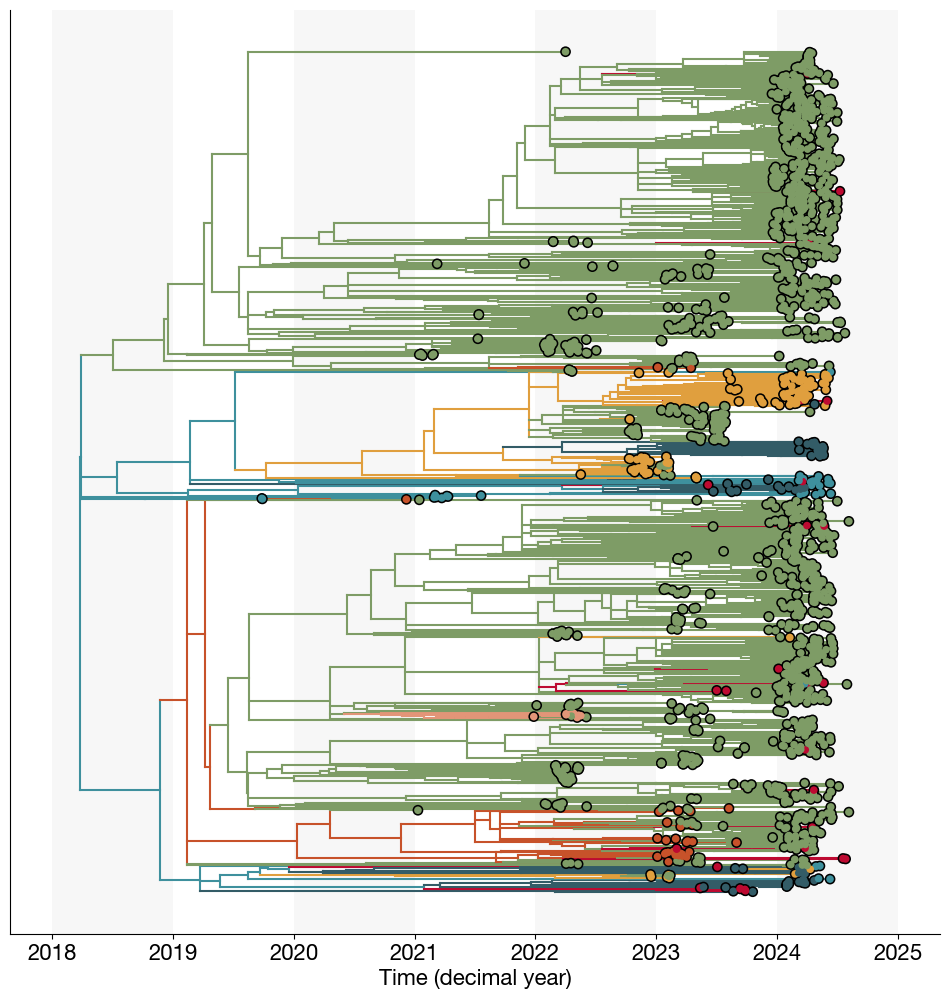

In [11]:
# Time-scaled tree visualisation
fig, ax = plt.subplots(figsize=(12, 12), facecolor="w")

ll.plotTree(
    ax,
    x_attr=lambda branch: getattr(branch, "absoluteTime", getattr(branch, "height", 0.0)),
    colour=c_func,
    width=1.5,
)
ll.plotPoints(
    ax,
    x_attr=lambda branch: getattr(branch, "absoluteTime", getattr(branch, "height", 0.0)),
    colour=c_func,
    size=30,
    zorder=5,
)

ax.set_xlabel("Time (decimal year)")
ax.set_ylabel("")
ax.set_title(f"")
ax.set_yticks([])

if most_recent_year is not None:
    earliest = min(getattr(branch, "absoluteTime", getattr(branch, "height", most_recent_year)) for branch in ll.Objects)
    years = range(int(earliest) - 1, int(most_recent_year) + 2)
    for year in years:
        if year % 2 == 0:
            ax.axvspan(year, year + 1, fc="k", ec="none", alpha=0.03, zorder=0)

plt.savefig("fullML_F112.jpeg", dpi=600, bbox_inches="tight")
plt.show()

In [12]:
# Optional: summarise branching by trait
import collections

summary = collections.Counter(
    branch.traits.get(COLOUR_TRAIT, "Unknown") for branch in ll.getExternal()
)

df = (
    pd.DataFrame.from_dict(summary, orient="index", columns=["tips"])
    .sort_values("tips", ascending=False)
)
df

,tips
Brazil,1494
Colombia,116
Ecuador,82
Peru,34
Bolivia,31
USA,30
Paraguay,8


In [13]:
import collections

BEAST_TREE_PATH = Path("../Revision/newMCCTree_F1112_Markov.mcc.tree")  # Nexus with decimal-time branch lengths
assert BEAST_TREE_PATH.exists(), f"Nexus tree not found at {BEAST_TREE_PATH}"

beast_tree = bt.loadNexus(
    str(BEAST_TREE_PATH),
    absoluteTime=True,
    sortBranches=True,
)

COLOUR_TRAIT = "location.rate"

summary = collections.Counter(
    branch.traits.get(COLOUR_TRAIT, "Unknown") for branch in beast_tree.getExternal()
)

df = (
    pd.DataFrame.from_dict(summary, orient="index", columns=["tips"])
    .sort_values("tips", ascending=False)
)
df

,tips
Colombia,155
Brazil,105
Ecuador,28
Bolivia,17
Peru,9
Paraguay,8
USA,5
Bangladesh,3
Other,2
